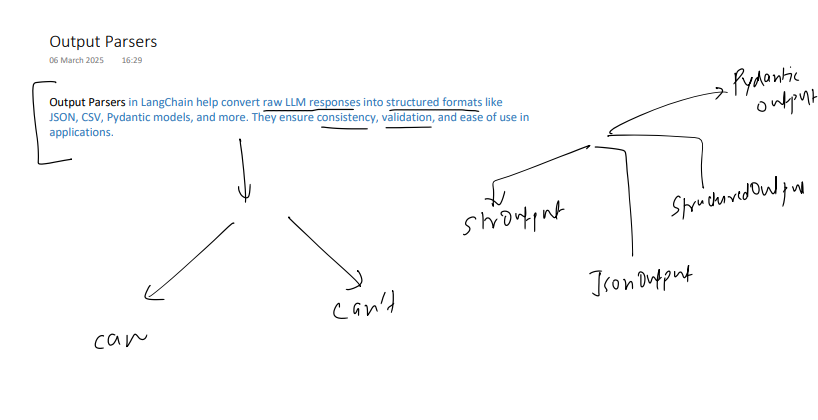

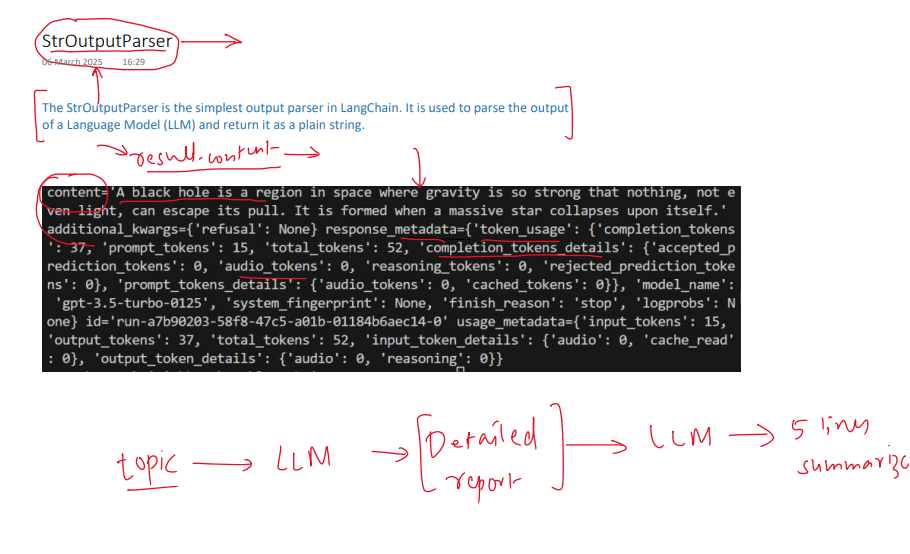

#### why we use stroutputparsers over result.content 
- shorts the code
- can use chains easily 

explain below by example =>
- topic given to the llm
- it create detailed report for the topic
- then report given to the llm
- it gives summary in 5 lines

In [2]:
#WITHOUT STROUTPUTPARSER
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate

load_dotenv()



model = ChatGroq(model ="openai/gpt-oss-120b")

# 1st prompt -> detailed report
template1 = PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)

# 2nd prompt -> summary
template2 = PromptTemplate(
    template='Write a 5 line summary on the following text. /n {text}',
    input_variables=['text']
)

prompt1 = template1.invoke({'topic':'black hole'})

result = model.invoke(prompt1)

prompt2 = template2.invoke({'text':result.content})

result1 = model.invoke(prompt2)

print(result1.content)


- Black holes are extreme spacetime regions predicted by General Relativity where gravity prevents even light from escaping, ranging from a few to billions of solar masses.  
- They form through stellar collapse, cluster dynamics, direct gas collapse, or possibly primordial density fluctuations, leading to stellar‑mass, intermediate‑mass, supermassive, and speculative primordial types.  
- Classified by mass, spin (Schwarzschild, Kerr, Reissner‑Nordström) and charge, they obey the “no‑hair” theorem, possess event horizons, singularities, and can emit Hawking radiation.  
- Observational proof comes from stellar dynamics (e.g., S‑stars around Sgr A*), X‑ray binaries, gravitational‑wave detections of mergers, and direct imaging of shadows by the Event Horizon Telescope.  
- Current theoretical challenges involve the information paradox, quantum‑gravity models (loop quantum gravity, string theory, AdS/CFT), and alternative compact objects such as gravastars or boson stars.


In [8]:
#USING STROUTPUTPARSER
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
load_dotenv()


model = ChatGroq(model ="openai/gpt-oss-120b")

# 1st prompt -> detailed report
template1 = PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)

# 2nd prompt -> summary
template2 = PromptTemplate(
    template='Write a 5 line summary on the following text. /n {text}',
    input_variables=['text']
)

parser = StrOutputParser()

# usuage of chains using parsers
chain = template1 | model | parser | template2 | model | parser 

result = chain.invoke({'topic':'black hole'})

print(result)


- Black holes are extreme spacetime regions predicted by General Relativity, where the event horizon marks a point of no return and singularities signal the breakdown of classical physics.  
- The report traces their theoretical origins—from Schwarzschild’s first solution to Kerr’s rotating metric and Hawking’s quantum radiation—while outlining four main classes: stellar‑mass, intermediate‑mass, supermassive, and primordial.  
- Formation pathways include massive‑star collapse, compact‑object mergers, direct gas‑cloud collapse, and early‑Universe density fluctuations that could produce primordial black holes.  
- Observational confirmation comes from stellar dynamics (e.g., Sgr A*), X‑ray binaries, gravitational‑wave detections of binary mergers, and direct imaging of event‑horizon shadows by the Event Horizon Telescope.  
- Black holes profoundly influence galaxy evolution, regulate star formation, and serve as laboratories for testing gravity, with future missions poised to resolve r

### JSONOutputParser

- converts the llm output into json 
- but can't enforce the schema on the json output --> can use structured output parser for this

In [5]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

load_dotenv()


model = ChatGroq(model ="openai/gpt-oss-120b")

parser = JsonOutputParser()

template = PromptTemplate(
    template='Give me 5 facts about {topic} \n {format_instruction}',
    input_variables=['topic'],
    partial_variables={'format_instruction': parser.get_format_instructions()}
)

chain = template | model | parser

result = chain.invoke({'topic':'black hole'})

print(result)


{'facts': ["A black hole's gravity is so strong that not even light can escape its event horizon.", "The size of a black hole's event horizon, called the Schwarzschild radius, is directly proportional to its mass.", 'Black holes can be detected by observing the effects of their gravity on nearby stars and gas, as well as by detecting gravitational waves from black hole mergers.', 'Supermassive black holes, millions to billions of times the mass of the Sun, reside at the centers of most galaxies, including our Milky Way.', 'Hawking radiation predicts that black holes can emit particles and gradually lose mass over extremely long timescales.']}


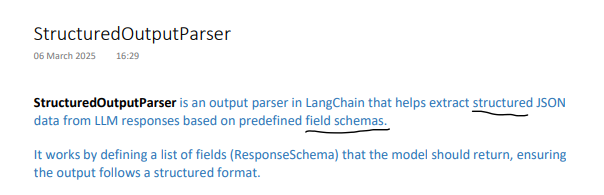

disadv => can't do data validation

In [6]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_classic.output_parsers.structured import StructuredOutputParser, ResponseSchema

load_dotenv()


model = ChatGroq(model ="openai/gpt-oss-120b")

schema = [
    ResponseSchema(name='fact_1', description='Fact 1 about the topic'),
    ResponseSchema(name='fact_2', description='Fact 2 about the topic'),
    ResponseSchema(name='fact_3', description='Fact 3 about the topic'),
]

parser = StructuredOutputParser.from_response_schemas(schema)

template = PromptTemplate(
    template='Give 3 fact about {topic} \n {format_instruction}',
    input_variables=['topic'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)

chain = template | model | parser

result = chain.invoke({'topic':'black hole'})

print(result)

{'fact_1': 'Black holes warp spacetime so strongly that not even light can escape from within their event horizon, making them invisible against the backdrop of space.', 'fact_2': "The size of a black hole's event horizon, called the Schwarzschild radius, scales linearly with its mass; a black hole with the mass of the Sun would have a radius of about 3 kilometers.", 'fact_3': 'Hawking radiation, a quantum effect predicted by Stephen Hawking, allows black holes to lose mass over extremely long timescales, eventually leading to their evaporation.'}


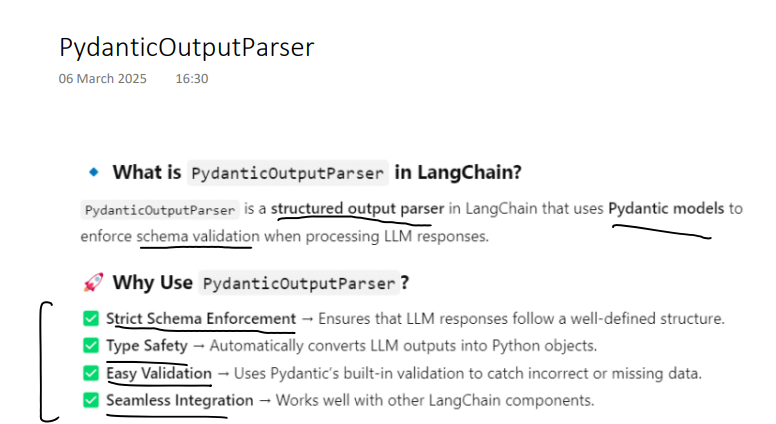

In [9]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

load_dotenv()


model = ChatGroq(model ="openai/gpt-oss-120b")

class Person(BaseModel):

    name: str = Field(description='Name of the person')
    age: int = Field(gt=18, description='Age of the person')
    city: str = Field(description='Name of the city the person belongs to')

parser = PydanticOutputParser(pydantic_object=Person)

template = PromptTemplate(
    template='Generate the name, age and city of a fictional {place} person \n {format_instruction}',
    input_variables=['place'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)

chain = template | model | parser

final_result = chain.invoke({'place':'sri lankan'})

print(final_result)

name='Nadeesha Perera' age=34 city='Kandy'


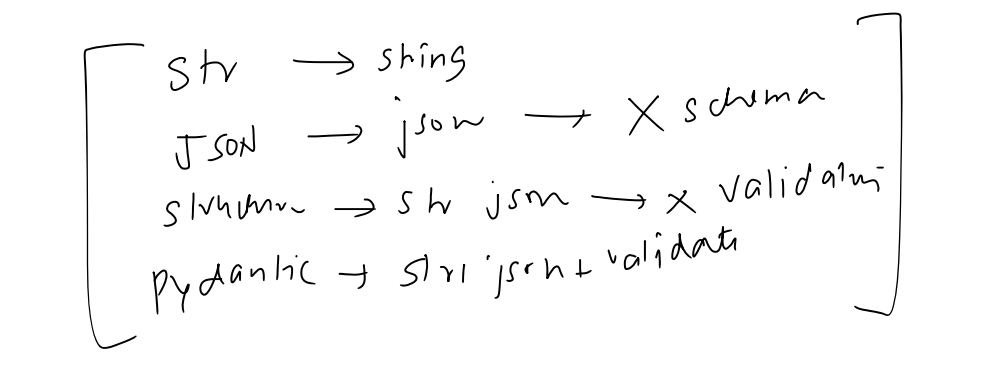